# 09 — Advanced SIEM Dataset (`darkknight25/Advanced_SIEM_Dataset`)

## 1. ¿De qué trata este dataset?
Es un conjunto de **100.000 eventos de seguridad sintéticos** en formato JSON Lines (`.jsonl`), diseñados para replicar la telemetría generada en un sistema corporativo **SIEM** (*Security Information and Event Management*).

* **8 categorías de eventos:** Firewall, IDS/IPS (ej. alertas Snort), autenticación (`auth`), endpoints/EDR, tráfico de red, entornos Cloud, dispositivos IoT e interacciones con sistemas de IA.
* **Estructura híbrida (Texto + Tabular + Metadatos anidados):**
  * **Comunes:** `event_id`, `timestamp`, `event_type`, `severity` (info a emergency), `source`.
  * **Log crudo (`raw_log`):** Cadenas en formato estándar **CEF** (*Common Event Format*).
  * **`advanced_metadata`:** Geolocalización, `device_hash`, `user_agent`, `session_id`, `risk_score` y `confidence`.
  * **`behavioral_analytics`:** Métricas UEBA como desviación de línea base, entropía y anomalías de frecuencia/secuencia.
  * **Atributos técnicos:** IPs origen/destino, puertos, protocolos, usuarios y técnicas **MITRE ATT&CK** (`T1059.001`, etc.).

---

## 2. ¿Con qué propósito se construyó?
* **Privacidad y confidencialidad:** Las empresas no pueden publicar sus logs reales de SIEM por normativas legales (GDPR, HIPAA) y porque revelarían su arquitectura de red interna, usuarios y vulnerabilidades.
* **Entorno de pruebas seguro:** Proporciona a investigadores y equipos de SecOps un volumen representativo de logs multiorigen para experimentar sin riesgo de exponer datos reales.

---

## 3. ¿En qué aporta y en qué se puede usar?
### Aportes clave
* **Unificación de telemetría:** Normaliza bajo un solo esquema eventos heterogéneos (red, identidad, nube y endpoint).
* **Doble nivel de análisis:** Permite trabajar simultáneamente con datos estructurados (tablas) y no estructurados (logs crudos en formato CEF).
* **Métricas analíticas precomputadas:** Incluye etiquetas de severidad y vectores de comportamiento (UEBA) listos para benchmarking.

> **Observación crítica del EDA:** Al ser sintético, la distribución de clases (tipos de evento y severidades) tiende a ser mucho más uniforme que en la vida real. En un SOC real, el 99% del tráfico es benigno (`info`/`low`) y menos del 1% es crítico.

### Casos de uso
1. **Detección de anomalías y amenazas:** Detección de fuerza bruta, movimiento lateral, balizamiento (*beaconing*) de C2 y accesos anómalos.
2. **Priorización y triage de alertas:** Modelos que re-categorizan el nivel de riesgo real para reducir la fatiga de alertas del SOC.
3. **Mapeo automático a MITRE ATT&CK:** Clasificación de eventos crudos contra técnicas tácticas del adversario.

---

## 4. ¿Qué modelos se pueden entrenar? ¿Son agentes, LLMs o ML clásico?
En un ecosistema real **no se usa una sola tecnología**, sino una arquitectura por niveles:

| Nivel | Tipo de Modelo | Ejemplos | Rol en este dataset |
| :--- | :--- | :--- | :--- |
| **Capa 1: Ingesta masiva (ML Clásico)** | Modelos tabulares / Detección numérica | **XGBoost, LightGBM, Random Forest, Isolation Forest** | Procesan campos numéricos (`risk_score`, entropía, puertos, bytes) a velocidad de sub-segundo para descartar el 95% del ruido benigno. |
| **Capa 2: Clasificación de texto (Deep Learning / Embeddings)** | Encoders ligeros | **DeBERTa-v3, RoBERTa, FastText** | Procesan el campo `raw_log` (CEF) y clasifican la severidad o técnica MITRE en milisegundos. |
| **Capa 3: Triage y Explicabilidad (LLMs)** | Modelos generativos compactos | **LLaMA 3 (8B), Mistral (7B), Qwen (7B)** con fine-tuning | Reciben las alertas que superaron el umbral de riesgo, interpretan el log crudo y redactan un informe claro para el analista humano. |
| **Capa 4: Respuesta Autónoma (Agentes IA)** | Orquestadores con acceso a herramientas (Tools) | Agentes basados en **LangChain, LangGraph o autogen** | **No se entrenan fila a fila con este dataset.** El dataset se utiliza como **banco de simulación** donde el agente recibe alertas del SIEM y decide qué acciones ejecutar (consultar VirusTotal, bloquear una IP en el firewall, o aislar un host). |

---

## 5. ¿Cómo quedaría funcionando en un sistema real?


1. **Ingesta:** Los firewalls y servidores envían logs crudos a un bus de mensajería (Kafka).
2. **Filtrado inicial rápido:** Un modelo clásico (XGBoost/Isolation Forest) evalúa millones de eventos por segundo con latencia inferior a 5 ms, descartando el tráfico normal.
3. **Enriquecimiento generativo:** Los eventos marcados como sospechosos se envían a un LLM local (LLaMA 3 8B), que traduce el log CEF crudo a lenguaje natural e identifica el impacto.
4. **Respuesta automatizada (SOAR / Agente):** El sistema ejecuta automáticamente el bloqueo preventivo y asigna el caso clasificado al analista del SOC con toda la evidencia lista.


In [1]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("09")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\09_darkknight25__Advanced_SIEM_Dataset
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\09_advanced_siem  (figures/, tables/)


## 1. Inventario de archivos

In [2]:
files = list_files(ctx.data_dir)
display(summarize_extensions(files))
display(files)

,n_archivos,size_mb
ext,,
.jsonl,1,93.725
.md,1,0.010
,1,0.003


,archivo,ext,size_mb
0,advanced_siem_dataset.jsonl,.jsonl,93.725
1,README.md,.md,0.010
2,.gitattributes,,0.003


## 2. Cargar (100k filas, cabe en memoria) y aplanar los objetos anidados

In [3]:
PATH = ctx.data_dir / "advanced_siem_dataset.jsonl"
raw = read_jsonl(PATH)
nested = [c for c in ["advanced_metadata", "behavioral_analytics"] if c in raw.columns]
flat = [pd.json_normalize(raw[c].apply(lambda x: x if isinstance(x, dict) else {})).add_prefix(f"{c}.") for c in nested]
df = pd.concat([raw.drop(columns=nested)] + flat, axis=1)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
print(df.shape)
display(df.head(3))
display(profile_df(df))

(100000, 43)


,event_id,timestamp,event_type,source,severity,raw_log,user,action,object,process_id,parent_process,additional_info,description,device_type,device_id,firmware_version,src_ip,dst_ip,alert_type,signature_id,category,cloud_service,resource_id,model_id,input_hash,output_hash,src_port,dst_port,protocol,bytes,duration,method,mac_address,advanced_metadata.geo_location,advanced_metadata.device_hash,advanced_metadata.user_agent,advanced_metadata.session_id,advanced_metadata.risk_score,advanced_metadata.confidence,behavioral_analytics.baseline_deviation,behavioral_analytics.entropy,behavioral_analytics.frequency_anomaly,behavioral_analytics.sequence_anomaly
0,8e785e09-5213-46b1-a6eb-b7e40998905b,2025-05-28 23:46:49,endpoint,Microsoft Sentinel v1.0.0,critical,CEF:0|Microsoft Sentinel v1.0.0|SIEM|1.0|100|endpoint|critical| desc=Endpoint file_access /I/fear.ppt by deannataylo...,deannataylor,file_access,/I/fear.ppt,8141.0,explorer.exe,No additional info,Endpoint file_access /I/fear.ppt by deannataylor No additional info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Isle of Man,d8595a4fb801a5ac7fcfe0987f50b16af71d52b2,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 5.01; Trident/5.0),c1a4c54e-e3c9-459f-88af-afb52bd1f220,61.04,0.33,1.84,3.6,False,False
1,bf4fa0a9-0665-40cd-ad81-6bdc84f189d4,2025-01-22 04:17:38,iot,AlienVault v5.7.0,low,CEF:0|AlienVault v5.7.0|SIEM|1.0|100|iot|low| desc=IoT device HVAC side_channel No additional info,NaN,side_channel,NaN,NaN,NaN,No additional info,IoT device HVAC side_channel No additional info,HVAC,iot-dc0f5947,9.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faroe Islands,05b6391883ff4291c88feeae6805a8020699e0db11a617cfdc0cd28044a93d91,"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/535.2 (KHTML, like Gecko) Chrome/25.0.828.0 Safari/535.2",c43a7bb6-111b-451b-bdd1-3c67cd8ece0a,53.84,0.40,NaN,NaN,NaN,NaN
2,e400e1b2-d174-43d0-8a17-f1f966a2b857,2025-03-21 10:03:20,ids_alert,Carbon Black v7.8.0,critical,CEF:0|Carbon Black v7.8.0|SIEM|1.0|100|ids_alert|critical| desc=Carbon Black Alert: Credential Stuffing detected fro...,NaN,NaN,NaN,NaN,NaN,No additional info,Carbon Black Alert: Credential Stuffing detected from 54.159.34.148 targeting N/A No additional info,NaN,NaN,NaN,54.159.34.148,N/A,Credential Stuffing,SIG-9267,Exploit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,63c4a533200b95fef99dc4d1b50c5a62,"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/532.2 (KHTML, like Gecko) Chrome/60.0.854.0 Safari/532.2",d31334f8-9de7-435a-8dbb-f27b5c356a5c,69.05,0.84,NaN,NaN,NaN,NaN


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
event_id,object,0,0.00,0,100000,36.0,36.0,36.0
timestamp,datetime64[ns],0,0.00,0,99716,NaN,NaN,NaN
event_type,object,0,0.00,0,8,5.7,5.0,9.0
source,object,0,0.00,0,20,16.0,16.0,25.0
severity,object,0,0.00,0,6,5.0,4.0,9.0
raw_log,object,0,0.00,0,97222,138.6,135.0,282.0
user,object,49717,49.72,0,40855,9.8,9.0,22.0
action,object,12500,12.50,0,55,12.1,13.0,23.0
object,object,87411,87.41,0,7379,11.6,12.0,32.0


## 3. Tipos de evento y severidad

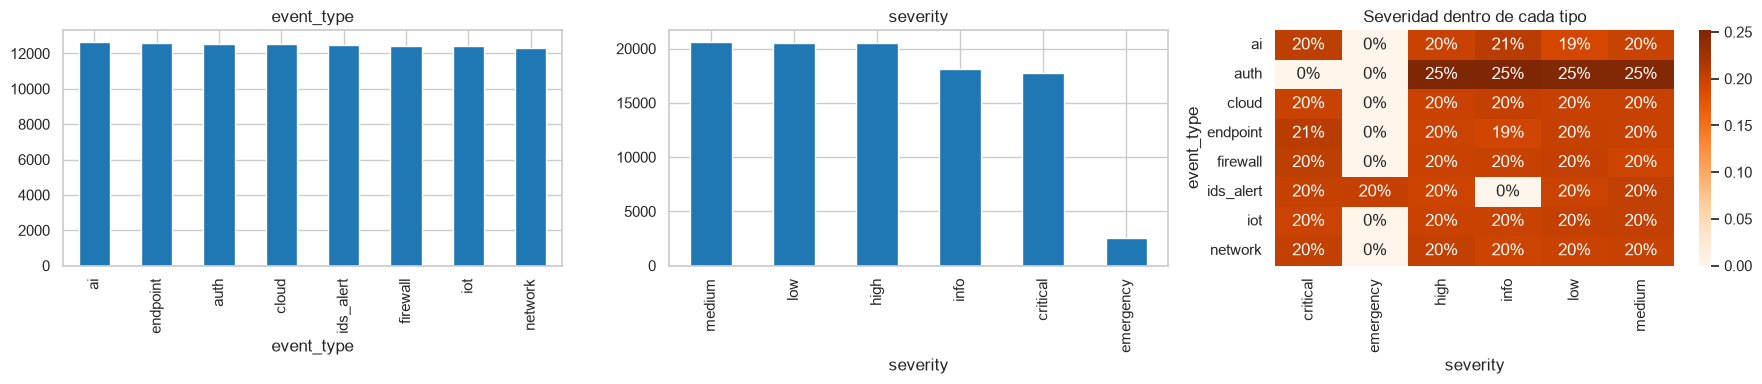

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
df["event_type"].value_counts().plot.bar(ax=axes[0]); axes[0].set_title("event_type")
df["severity"].value_counts().plot.bar(ax=axes[1]); axes[1].set_title("severity")
sns.heatmap(pd.crosstab(df["event_type"], df["severity"], normalize="index"), annot=True, fmt=".0%", cmap="Oranges", ax=axes[2])
axes[2].set_title("Severidad dentro de cada tipo")
plt.tight_layout(); save_fig(fig, ctx, "tipos_y_severidad"); plt.show()

## 4. Columnas por tipo de evento
Muchas columnas solo aplican a un tipo de evento; el mapa muestra el % de valores no nulos.

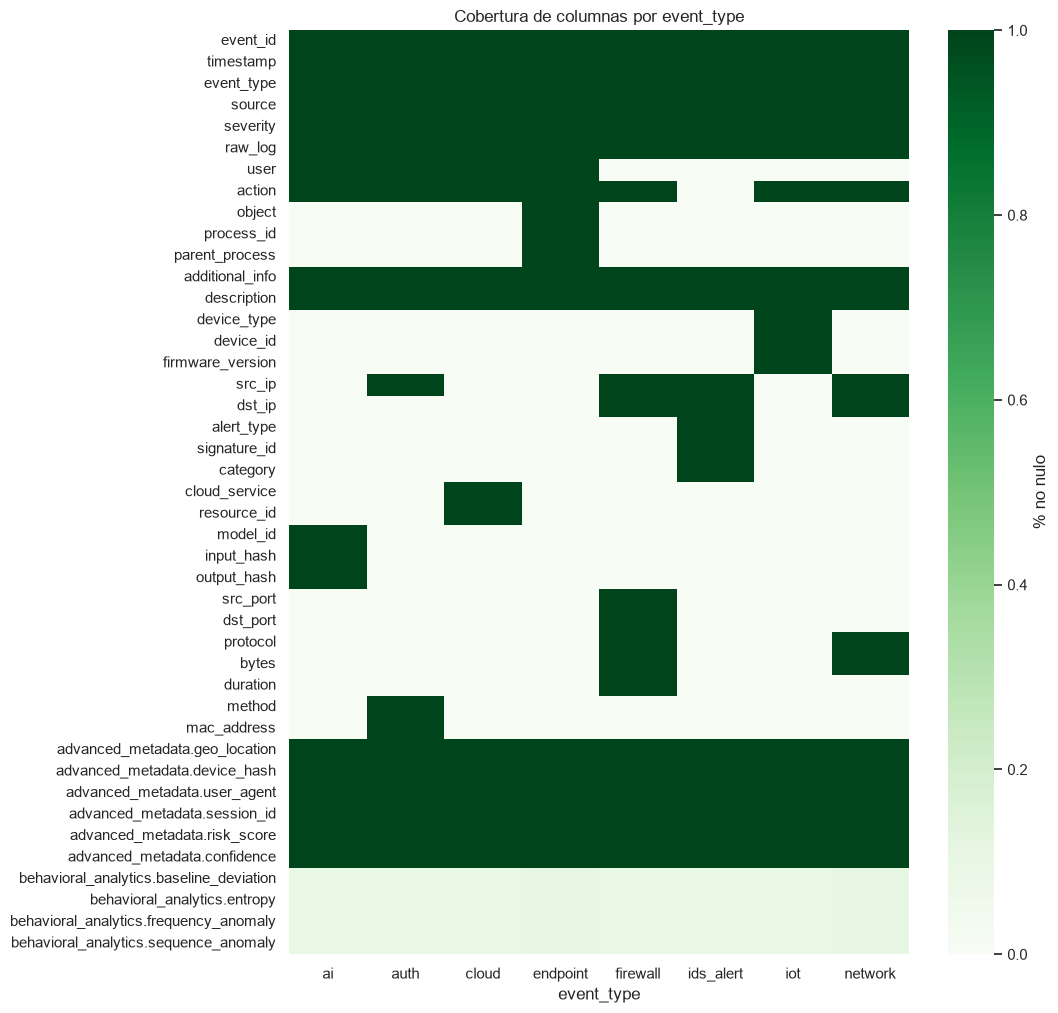

In [5]:
fill = df.notna().groupby(df["event_type"]).mean().T
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(fill, cmap="Greens", ax=ax, cbar_kws={"label": "% no nulo"})
ax.set_title("Cobertura de columnas por event_type"); save_fig(fig, ctx, "cobertura_columnas"); plt.show()

## 5. Tiempo y puntajes

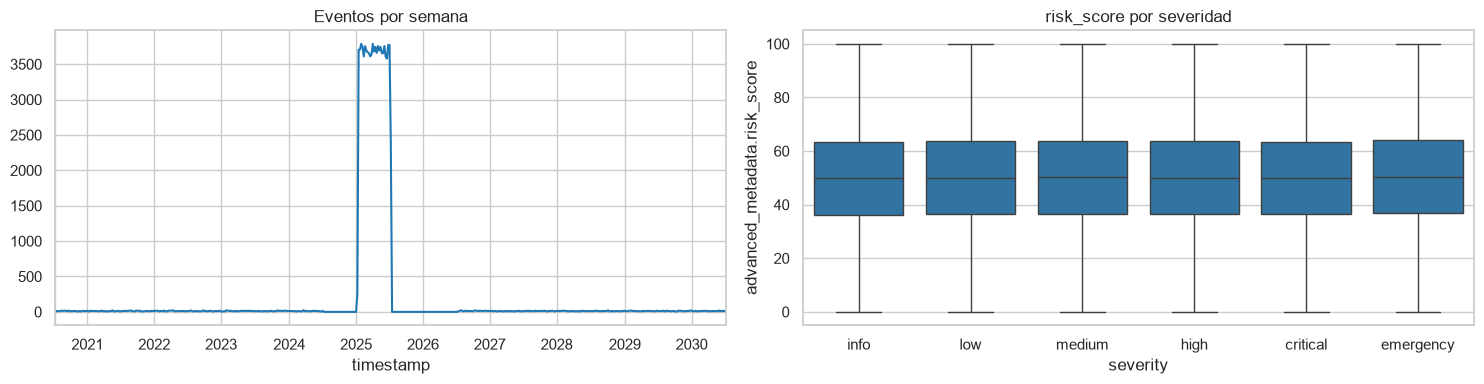

Rango de fechas: 2020-07-12 21:38:20 → 2030-07-10 06:49:21


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df.set_index("timestamp").resample("W").size().plot(ax=axes[0]); axes[0].set_title("Eventos por semana")
if "advanced_metadata.risk_score" in df:
    sns.boxplot(data=df, x="severity", y="advanced_metadata.risk_score", ax=axes[1],
                order=["info", "low", "medium", "high", "critical", "emergency"])
    axes[1].set_title("risk_score por severidad")
plt.tight_layout(); save_fig(fig, ctx, "tiempo_y_riesgo"); plt.show()
print("Rango de fechas:", df["timestamp"].min(), "→", df["timestamp"].max())

In [7]:
for c in ["source", "action", "advanced_metadata.geo_location", "alert_type", "category", "protocol"]:
    if c in df:
        print(f"\n--- {c} (top 10 de {df[c].nunique()}) ---")
        display(df[c].value_counts().head(10).to_frame("n"))


--- source (top 10 de 20) ---


,n
source,
ArcSight v7.4.0,5134
OSSEC v3.7.0,5101
AlienVault v5.7.0,5080
FireEye HX v4.5.0,5078
CrowdStrike v6.45.0,5069
Zeek v5.0.0,5026
Splunk v9.0.2,5021
Suricata v6.0.10,5006
Trellix v10.7.0,4995



--- action (top 10 de 55) ---


,n
action,
api_abuse,2935
bypass,2172
locked,2095
log-only,2091
inspect,2088
failed,2086
allow,2081
drop,2080
success,2067



--- advanced_metadata.geo_location (top 10 de 245) ---


...

,n
alert_type,
Zero-Day Exploit,810
MFA Bypass,791
Credential Stuffing,784
Supply Chain Compromise,767
XSS,762
Brute Force,749
Port Scan,744
DNS Tunneling,738
DDoS,735



--- category (top 10 de 5) ---


,n
category,
Evasion,2556
Policy,2534
Recon,2509
Malware,2453
Exploit,2448



--- protocol (top 10 de 10) ---


,n
protocol,
TCP,3827
ICMP,3723
UDP,3676
HTTPS,3673
HTTP,3637
SSH,1290
RDP,1277
NTP,1246
DNS,1224


## 6. Ejemplos de logs crudos

In [8]:
show_examples(df, n=4, cols=["event_type", "severity", "raw_log"], max_chars=300)

fila 3582
--- event_type ---
endpoint
--- severity ---
critical
--- raw_log ---
CEF:0|OSSEC v3.7.0|SIEM|1.0|100|endpoint|critical| desc=Endpoint registry_change /church/than.mov by tandrews No additional info
fila 60498
--- event_type ---
cloud
--- severity ---
medium
--- raw_log ---
CEF:0|OSSEC v3.7.0|SIEM|1.0|100|cloud|medium| desc=Cloud permission_escalation in AWS by christopherandrews MITRE Technique: T1574.002
fila 53227
--- event_type ---
firewall
--- severity ---
high
--- raw_log ---
CEF:0|QRadar v7.5.0|SIEM|1.0|100|firewall|high| desc=Firewall log-only UDP traffic from 19.108.171.157:12981 to 170.3.50.107:714 No additional info
fila 21333
--- event_type ---
firewall
--- severity ---
critical
--- raw_log ---
CEF:0|Microsoft Sentinel v1.0.0|SIEM|1.0|100|firewall|critical| desc=Firewall drop TCP traffic from 35.34.36.187:17837 to 44.81.103.239:584 Associated Threat Actor: Leafminer noise=blog/explore
